# 3. Network Inference: Pseudobulk (MRA + RP + FPTU)

Pseudobulk network inference on the core genes selected in Notebook 2, using `cstarpy.inference` (`run_mra` -> `run_mra_rp` -> `run_regularized_mra_fptu`).

**Naming convention:** `R` (observed data, capital), `r`/`r_fptu`/`r_total` (local response, lowercase), `r_minv` (`-pinv(r_total)`, still lowercase).

**Cytoscape export.** A `From / To / Strength` tab-separated file, ready for File > Import > Network in Cytoscape Desktop.

### 1. Configuration

In [1]:
import os
print(f'Working directory: {os.getcwd()}')

Working directory: /mnt/R0/Projects/POIAZ/Ilaria/Scripts


In [2]:
# Must match Notebooks 1-2
CONDITION = 'Stim48hr'  # 'Rest', 'Stim8hr', 'Stim48hr'
DONORS = ['D1', 'D2', 'D3', 'D4']
donors_tag = '_'.join(DONORS)
run_tag = f'{CONDITION}_{donors_tag}'

# Paths
CORE_GENES_DIR = f'../Results/{CONDITION}' # Notebook 2 output (core_genes)
OUT_DIR = f'../Results/{CONDITION}/pseudobulk' # Notebook 2 output (R) AND this notebook's own outputs
os.makedirs(OUT_DIR, exist_ok=True)

# MRA (initial pass)
MRA_METHOD = 'br'
MRA_PVALUE_THRESHOLD = 0.05

# RP (Regularized Perturbation)
RP_ALPHA_INIT = 1.0 # PerturbationMagnitude.estimate() regularization
RP_METHOD = 'ols'
RP_ALPHA = 10.0 # regularization inside the RP loop
RP_RELAX = 0.005 # per-iteration update damping (close to 0 = small, cautious steps)
RP_N_ITER = 1200

# FPTU
FPTU_METHOD = 'ols'
FPTU_THRESHOLD = 0.1
FPTU_PVALUE_THRESHOLD = 0.4

# Alternate settings for the stability/sensitivity check (Section 6c)
RP_N_ITER_ALT = 1200
RP_RELAX_ALT = 0.0025

# Display parameters for figures
TOP_N_HEATMAP = 30 # genes shown in the r/cosine heatmaps, ranked by |DPD_stim_norm|
EDGE_STRENGTH_PERCENTILE = 80 # edges kept in the network figure (among top_genes only): top (100-this)% by |strength|
HUB_DEGREE_LABEL_MIN = 3  # only label nodes with at least this total degree in the graph

print(f'run_tag: {run_tag}')
print(f'Out dir: {OUT_DIR}')

run_tag: Stim48hr_D1_D2_D3_D4
Out dir: ../Results/Stim48hr/pseudobulk


Package imports, including `cstarpy` (MRA + RP + FPTU) and `networkx` for the network figure.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import cstarpy.inference
from cstarpy.preprocessing import PerturbationMagnitude

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 11
print('Packages loaded.')

Packages loaded.


### 2. Load Core Genes and R

The core genes selected in Notebook 2, with their DPD scores (needed later for FPTU and for node colouring).

In [4]:
core_df = pd.read_csv(os.path.join(CORE_GENES_DIR, f'core_genes_{run_tag}.csv'))
core_genes = core_df['target_contrast_gene_name'].tolist()
N = len(core_genes)
dpd_stim_lookup = core_df.set_index('target_contrast_gene_name')['DPD_stim_norm']

print(f'Core genes: {N}')
print(f'DPD_stim_norm range: [{core_df["DPD_stim_norm"].min():.3f}, {core_df["DPD_stim_norm"].max():.3f}]')

Core genes: 200
DPD_stim_norm range: [-23.398, 2.485]


**R (observed data, input to MRA):** built in Notebook 2, loaded here directly. Square, core genes on both axes (rows = perturbation, columns = response of the same genes).

In [5]:
R_df = pd.read_csv(os.path.join(OUT_DIR, f'R_{run_tag}.csv'), index_col=0)
R = R_df.values
print(f'R: {R_df.shape}')

R: (200, 200)


`pert`: each core gene has exactly one perturbation experiment, itself, so `pert` is the NxN identity matrix. `G_not`: only self-connections forbidden, no curated prior.

In [6]:
pert_df = pd.DataFrame(np.eye(N, dtype=np.int8), index=core_genes, columns=core_genes)
G_not_df = pd.DataFrame(np.eye(N, dtype=bool), index=core_genes, columns=core_genes)
print(f'pert: {pert_df.shape}, {int(pert_df.values.sum())} perturbation entries (expect {N})')

pert: (200, 200), 200 perturbation entries (expect 200)


### 3. MRA (initial pass)

`run_mra` with `method='br'` (Bayesian Ridge). This is the starting point that RP (Section 4) will refine.

In [7]:
r_arr = cstarpy.inference.run_mra(
    R_df.to_numpy(dtype=np.float64),
    pert_df.to_numpy(dtype=bool),
    G_not=G_not_df.to_numpy(),
    method=MRA_METHOD,
    pvalue_threshold=MRA_PVALUE_THRESHOLD,
    show_progress_bar=True,
)
np.fill_diagonal(r_arr, -1)
r = pd.DataFrame(r_arr, index=core_genes, columns=core_genes)
print(f'r (initial, method={MRA_METHOD}): {r.shape}')
print(f'Non-zero local responses: {(r.to_numpy() != 0).sum() - N} (excluding diagonal)')

100%|██████████| 200/200 [00:06<00:00, 30.76it/s]

r (initial, method=br): (200, 200)
Non-zero local responses: 928 (excluding diagonal)


### 4. RP (Regularized Perturbation)

Alternates between re-estimating `r` and re-estimating `rp` (how much each gene was actually perturbed, not just the nominal on/off `pert`), for `RP_N_ITER` iterations. Does not stop early on convergence, runs the full budget, then picks the iteration with the smallest change from the previous one (not necessarily the last). The convergence plot below is how we check whether that budget was actually enough.

In [8]:
rp_init = PerturbationMagnitude(R=R_df, pert=pert_df, r=r)
rp_init.estimate(alpha=RP_ALPHA_INIT)

rps_diff, r_mean, rp_final = cstarpy.inference.run_mra_rp(
    R_df,
    pert_df,
    G_not=G_not_df.to_numpy(),
    method=RP_METHOD,
    pvalue_threshold=MRA_PVALUE_THRESHOLD,
    alpha=RP_ALPHA,
    rp_init=rp_init,
    rp_relax=RP_RELAX,
    n_iter=RP_N_ITER,
    show_progress_bar=True,
)

r_arr = np.asarray(r_mean, dtype=np.float64).copy()
np.fill_diagonal(r_arr, -1)
r = pd.DataFrame(r_arr, index=core_genes, columns=core_genes)
print(f'r (after RP): {r.shape}')
print(f'Non-zero local responses: {(r.to_numpy() != 0).sum() - N} (excluding diagonal)')

100%|██████████| 1200/1200 [31:19<00:00,  1.57s/it]

r (after RP): (200, 200)
Non-zero local responses: 39800 (excluding diagonal)


Convergence check: has `rps_diff` flattened out within the `RP_N_ITER` budget, or is it still decreasing linearly at the end (a sign more iterations are needed)?

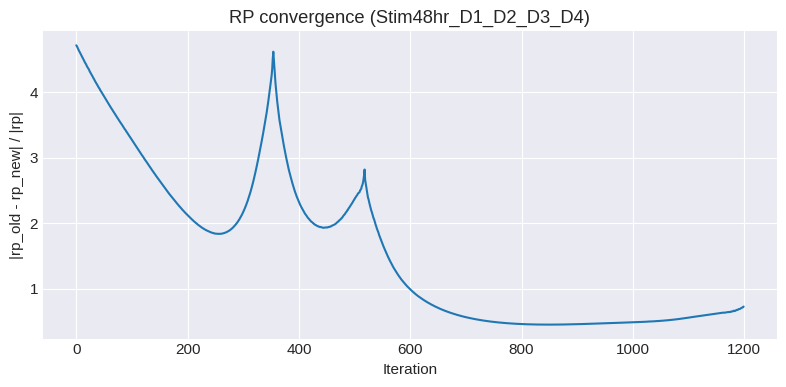

Saved: ../Results/Stim48hr/pseudobulk/rp_convergence_Stim48hr_D1_D2_D3_D4.png
Final rps_diff: 0.731245 | Min rps_diff (selected iteration): 0.455891


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(len(rps_diff)), rps_diff)
ax.set_xlabel('Iteration')
ax.set_ylabel('|rp_old - rp_new| / |rp|')
ax.set_title(f'RP convergence ({run_tag})')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'rp_convergence_{run_tag}.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')
print(f'Final rps_diff: {rps_diff[-1]:.6f} | Min rps_diff (selected iteration): {min(rps_diff):.6f}')

### 5. FPTU: extend r to DPD modules

`DPD_stim` is scaled by its own max absolute value before FPTU, and the result rescaled back afterward. Without this, the huge difference in scale between `DPD_stim_norm` (can reach the tens) and `R`'s logFC-scale entries (typically well under 1) can destabilise the regression. By construction, FPTU only allows perturbed-to-unperturbed connections, so the DPD module can never be a source of an edge.

In [10]:
dpd_values = dpd_stim_lookup.reindex(core_genes).to_numpy(dtype=np.float64)
dpd_scale = float(np.abs(dpd_values).max())
data_unperturbed_scaled = (dpd_values / dpd_scale)[None, :]

G_not_fptu = np.zeros((1, N), dtype=bool)

def run_fptu_with_retry(thresholds=(0.1, 0.05, 0.01, 0.005, 0.001)):
    for t in thresholds:
        try:
            arr = cstarpy.inference.run_regularized_mra_fptu(
                data_perturbed=R_df.to_numpy(dtype=np.float64),
                data_unperturbed=data_unperturbed_scaled,
                pert=pert_df.to_numpy(dtype=bool),
                G_not=G_not_fptu,
                method=FPTU_METHOD,
                threshold=t,
                pvalue_threshold=FPTU_PVALUE_THRESHOLD,
            )
            print(f'FPTU converged at threshold={t}')
            return arr, t
        except ValueError as e:
            if 'threshold' not in str(e):
                raise
            print(f'FPTU: threshold={t} failed ({e}), retrying lower...')
    raise RuntimeError(f'FPTU did not converge for any threshold in {thresholds}')

r_fptu_scaled, fptu_threshold_used = run_fptu_with_retry()

dpd_module_names = ['DPD_stim']
r_fptu = pd.DataFrame(np.asarray(r_fptu_scaled) * dpd_scale, index=dpd_module_names, columns=core_genes)
print(f'DPD scale factor: {dpd_scale:.4f}')
print(f'r_fptu: {r_fptu.shape}')
print(f'Non-zero entries: {(r_fptu.to_numpy() != 0).sum()} / {N}')
print(r_fptu.loc['DPD_stim'].sort_values().to_string())

 40%|████      | 4/10 [00:00<00:00, 65.01it/s]


FPTU: threshold=0.1 failed (`threshold` is too large. Please consider setting it to a lower value.), retrying lower...


100%|██████████| 10/10 [00:00<00:00, 74.26it/s]

FPTU converged at threshold=0.05
DPD scale factor: 23.3985
r_fptu: (1, 200)
Non-zero entries: 125 / 200
ING3       -19.113239
ANKRD61    -17.174313
NCAPG2     -15.900570
TP53INP2   -15.266645
HIF1A      -12.923380
GATA3       -8.940874
CLASRP      -8.795240
NAA30       -8.654704
RNFT2       -8.331388
EIF3L       -8.045634
DEF8        -7.950307
LIG3        -7.377688
N6AMT1      -6.866059
UBE2V2      -6.663871
DPH5        -5.898590
USP22       -5.507555
CNOT4       -5.409802
SMARCB1     -5.289946
DDOST       -5.159271
DOLPP1      -5.096917
TAF13       -4.979237
MRC2        -4.870162
MOV10       -4.768287
TM2D1       -4.530637
IL2RB       -4.244262
ACOT7       -4.087277
CCNT1       -3.892211
CD5         -3.812222
SGF29       -3.748752
ELOB        -3.647100
TUFM        -3.493741
LRBA        -3.434824
TBX21       -3.393806
SP2         -3.334263
LOXL2       -3.282819
METTL1      -3.266457
RIDA        -3.099464
CD2         -3.058515
KAT7        -3.031967
SCYL3       -2.948119
COA6        -2.8

Assemble `r` and `r_fptu` into one matrix, `r_total`, with the DPD module appended as an extra row (never as a column). Diagonal is fixed on the raw array before wrapping in a DataFrame, `DataFrame.values` can silently return a copy rather than a view, which previously left `r`'s own diagonal unfixed even though the code looked correct.

In [11]:
all_nodes = core_genes + dpd_module_names
r_total_arr = np.zeros((len(all_nodes), len(all_nodes)))
r_total_arr[:N, :N] = r.to_numpy()
r_total_arr[N:, :N] = r_fptu.to_numpy()
np.fill_diagonal(r_total_arr, -1)
r_total = pd.DataFrame(r_total_arr, index=all_nodes, columns=all_nodes)

print(f'r_total: {r_total.shape}')

r_total: (201, 201)


### r_minv (global response)

In [12]:
r_minv_arr = -np.linalg.pinv(r_total_arr)
r_minv = pd.DataFrame(r_minv_arr, index=all_nodes, columns=all_nodes)
print(f'r_minv: {r_minv.shape}')

r_minv: (201, 201)


### 6. Diagnostics

Three checks on whether the RP/FPTU parameters behave reasonably at 200 genes, none of them require deciding on better parameter values up front.

**6a. RP convergence** already plotted in Section 4. Re-stated here for reference.

In [13]:
print(f'RP ran for {len(rps_diff)} iterations.')
print(f'rps_diff: final={rps_diff[-1]:.6f}, min={min(rps_diff):.6f}, at iteration {int(np.argmin(rps_diff))}')
if rps_diff[-1] > 2 * min(rps_diff):
    print('NOTE: final iteration is well above the minimum -- the selected (best) iteration '
          'is not the last one. Not necessarily a problem (that is what the argmin selection '
          'is for), but worth a second look if this gap is large.')

RP ran for 1200 iterations.
rps_diff: final=0.731245, min=0.455891, at iteration 849


**6b. Predicted vs observed correlation.** reconstruct the systems-level response from the inferred network (`R_I_pred = -r_total^{-1} . r_I`, where `r_I` is the observed data restricted to actual perturbation events) and correlate against what was actually observed. A low correlation here is a direct, external sign that something is off with the inferred network, independent of any single gene's behaviour.

Predicted vs observed correlation: 0.2929


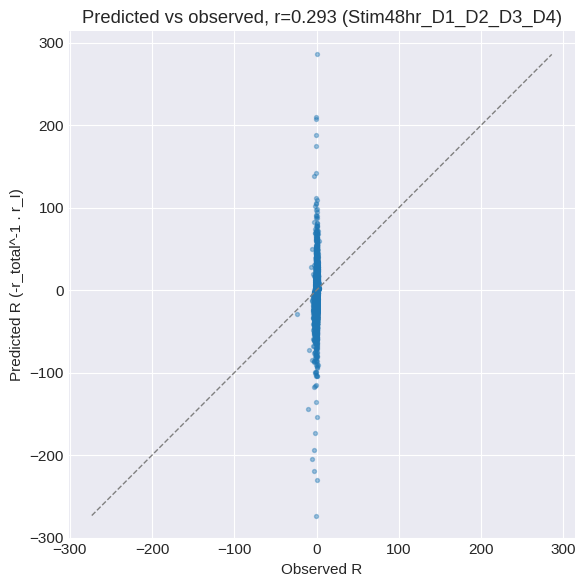

Saved: ../Results/Stim48hr/pseudobulk/predicted_vs_observed_Stim48hr_D1_D2_D3_D4.png


In [14]:
R_with_dpd = pd.concat([
    R_df,
    pd.DataFrame(dpd_values[None, :], index=['DPD_stim'], columns=core_genes),
])
pert_full = pert_df.reindex(index=all_nodes, fill_value=0)

r_I = R_with_dpd.reindex(index=all_nodes).fillna(0).to_numpy() * pert_full.to_numpy()
R_I_pred = r_minv_arr @ r_I
observed = R_with_dpd.reindex(index=all_nodes).to_numpy()

pred_obs_corr = float(np.corrcoef(R_I_pred.flatten(), observed.flatten())[0, 1])
print(f'Predicted vs observed correlation: {pred_obs_corr:.4f}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(observed.flatten(), R_I_pred.flatten(), s=8, alpha=0.4)
lims = [min(observed.min(), R_I_pred.min()), max(observed.max(), R_I_pred.max())]
ax.plot(lims, lims, color='grey', lw=1, linestyle='--')
ax.set_xlabel('Observed R')
ax.set_ylabel('Predicted R (-r_total^-1 . r_I)')
ax.set_title(f'Predicted vs observed, r={pred_obs_corr:.3f} ({run_tag})')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'predicted_vs_observed_{run_tag}.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

**6c. Stability check.** Reruns only the RP step with `RP_N_ITER_ALT`/`RP_RELAX_ALT` (starting from the same `rp_init`, so this isolates the effect of those two parameters) and compares the resulting `r` against the one used above. High correlation and small typical difference mean the main result is not sensitive to these exact values within this range; a large change means they matter more at this scale, and is worth discussing before trusting the network too far.

In [15]:
# _, r_mean_alt, _ = cstarpy.inference.run_mra_rp(
#     R_df,
#     pert_df,
#     G_not=G_not_df.to_numpy(),
#     method=RP_METHOD,
#     pvalue_threshold=MRA_PVALUE_THRESHOLD,
#     alpha=RP_ALPHA,
#     rp_init=rp_init,
#     rp_relax=RP_RELAX_ALT,
#     n_iter=RP_N_ITER_ALT,
#     show_progress_bar=True,
# )
# r_arr_alt = np.asarray(r_mean_alt, dtype=np.float64).copy()
# np.fill_diagonal(r_arr_alt, -1)

# off_diag_mask = ~np.eye(N, dtype=bool)
# stability_corr = float(np.corrcoef(r_arr[off_diag_mask], r_arr_alt[off_diag_mask])[0, 1])
# mean_abs_diff = float(np.abs(r_arr[off_diag_mask] - r_arr_alt[off_diag_mask]).mean())
# print(f'Stability check (RP_N_ITER={RP_N_ITER} vs {RP_N_ITER_ALT}, '
#       f'RP_RELAX={RP_RELAX} vs {RP_RELAX_ALT}):')
# print(f'  Correlation between the two r matrices (off-diagonal): {stability_corr:.4f}')
# print(f'  Mean absolute difference (off-diagonal): {mean_abs_diff:.4f}')

# diagnostics_summary = pd.DataFrame([
#     {'check': 'rp_convergence_final', 'value': rps_diff[-1]},
#     {'check': 'rp_convergence_min', 'value': min(rps_diff)},
#     {'check': 'predicted_vs_observed_correlation', 'value': pred_obs_corr},
#     {'check': 'stability_correlation', 'value': stability_corr},
#     {'check': 'stability_mean_abs_diff', 'value': mean_abs_diff},
# ])
# print()
# print(diagnostics_summary.to_string(index=False))

### 7. Visualisations

**Top drivers of the DPD_stim module (`r_fptu`).** Direct answer to "which genes control activation": the core genes with the strongest local response into the module, both directions.

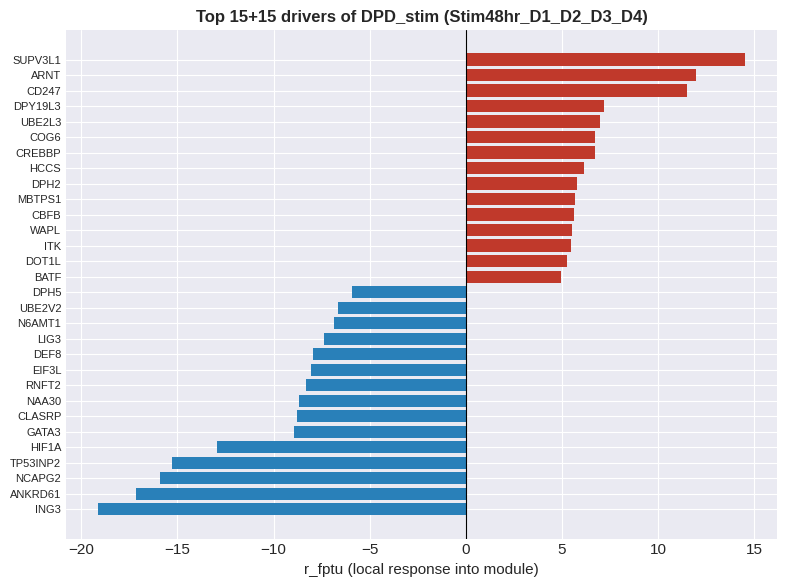

Saved: ../Results/Stim48hr/pseudobulk/r_fptu_top_drivers_Stim48hr_D1_D2_D3_D4.png


In [16]:
TOP_N_FPTU = 15

fig, ax = plt.subplots(figsize=(8, 6))
vals = r_fptu.loc['DPD_stim'].sort_values()
combined = pd.concat([vals.head(TOP_N_FPTU), vals.tail(TOP_N_FPTU)])
colors = ['#2980b9' if v < 0 else '#c0392b' for v in combined]
ax.barh(combined.index, combined.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title(f'Top {TOP_N_FPTU}+{TOP_N_FPTU} drivers of DPD_stim ({run_tag})', fontsize=12, fontweight='bold')
ax.set_xlabel('r_fptu (local response into module)')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
p = os.path.join(OUT_DIR, f'r_fptu_top_drivers_{run_tag}.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

Heatmap of `r`, restricted to the top genes by |DPD_stim_norm| for readability.

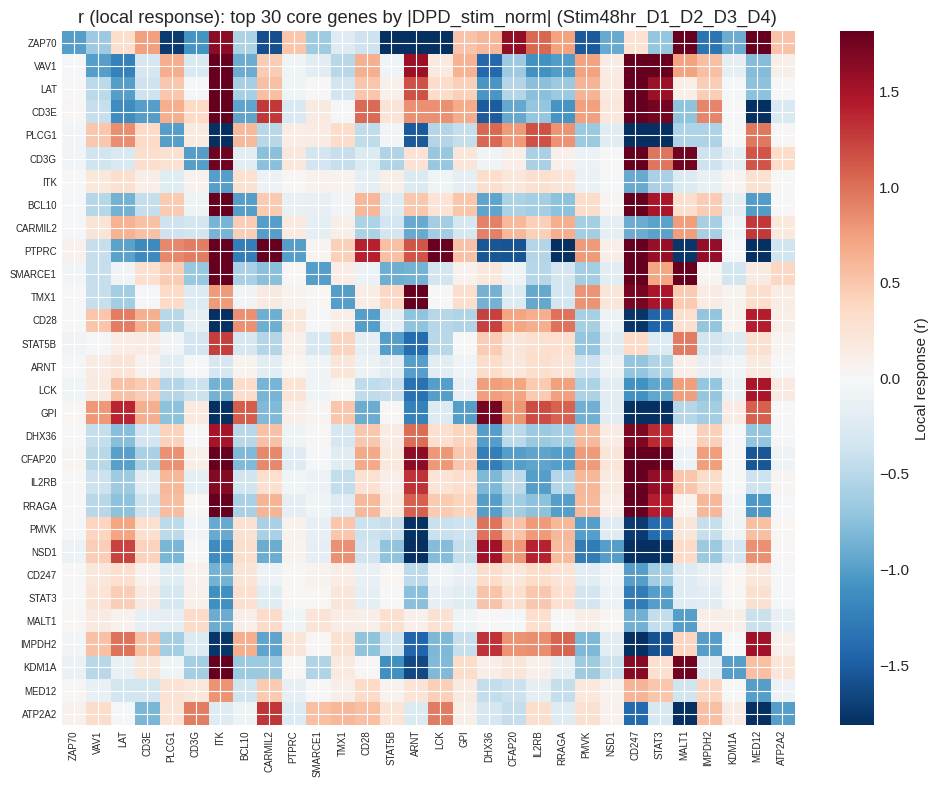

Saved: ../Results/Stim48hr/pseudobulk/r_heatmap_top30_Stim48hr_D1_D2_D3_D4.png


In [17]:
top_genes = core_df.reindex(
    core_df['DPD_stim_norm'].abs().sort_values(ascending=False).index
)['target_contrast_gene_name'].head(TOP_N_HEATMAP).tolist()

r_sub = r.loc[top_genes, top_genes].to_numpy()
vmax = np.percentile(np.abs(r_sub[~np.eye(len(r_sub), dtype=bool)]), 95)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(r_sub, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(top_genes)))
ax.set_yticks(range(len(top_genes)))
ax.set_xticklabels(top_genes, rotation=90, fontsize=7)
ax.set_yticklabels(top_genes, fontsize=7)
ax.set_title(f'r (local response): top {TOP_N_HEATMAP} core genes by |DPD_stim_norm| ({run_tag})')
plt.colorbar(im, ax=ax, label='Local response (r)')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'r_heatmap_top{TOP_N_HEATMAP}_{run_tag}.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

Cosine-similarity heatmap of the raw `R` response profiles, same top-gene subset. Shows which perturbations produce similar transcriptional responses regardless of magnitude.

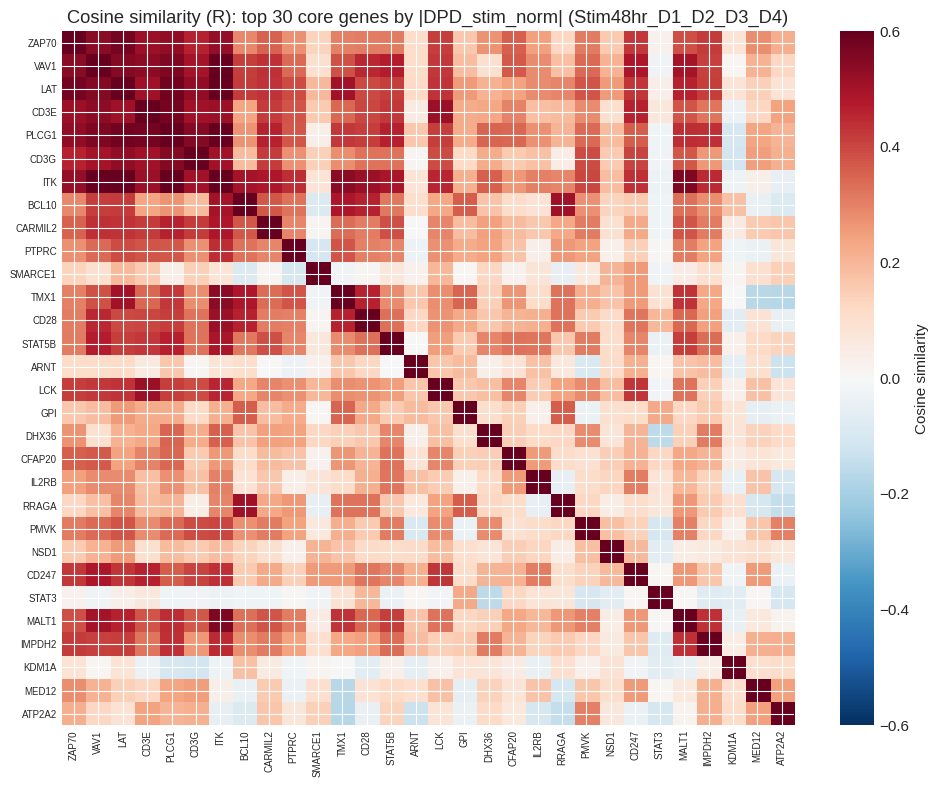

Saved: ../Results/Stim48hr/pseudobulk/cosine_heatmap_top30_Stim48hr_D1_D2_D3_D4.png


In [18]:
cosine_R = cosine_similarity(R_df.loc[top_genes].to_numpy())

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cosine_R, cmap='RdBu_r', vmin=-0.6, vmax=0.6, aspect='auto')
ax.set_xticks(range(len(top_genes)))
ax.set_yticks(range(len(top_genes)))
ax.set_xticklabels(top_genes, rotation=90, fontsize=7)
ax.set_yticklabels(top_genes, fontsize=7)
ax.set_title(f'Cosine similarity (R): top {TOP_N_HEATMAP} core genes by |DPD_stim_norm| ({run_tag})')
plt.colorbar(im, ax=ax, label='Cosine similarity')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'cosine_heatmap_top{TOP_N_HEATMAP}_{run_tag}.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

Directed network graph, restricted to `top_genes` (the same subset as the heatmaps above) plus the DPD module, otherwise unreadable at this node count. Edges among `top_genes` are thresholded to the top `100 - EDGE_STRENGTH_PERCENTILE`% strongest connections within that subset; edges into the DPD module are always shown regardless of threshold. Node colour encodes DPD role (activator / suppressor / DPD module), edge colour encodes sign (activation / inhibition), arrows show directionality. Only hub genes (total degree >= `HUB_DEGREE_LABEL_MIN`) are labelled.

In [19]:
graph_nodes = top_genes + dpd_module_names

gene_sub = r_total.loc[top_genes, top_genes].to_numpy()
off_diag_vals = gene_sub[~np.eye(len(top_genes), dtype=bool)]
threshold = np.percentile(np.abs(off_diag_vals), EDGE_STRENGTH_PERCENTILE)
print(f'Edge strength threshold among top_genes ({EDGE_STRENGTH_PERCENTILE}th percentile): {threshold:.4f}')

edge_rows = []
for target in top_genes:
    for source in top_genes:
        if source == target:
            continue
        strength = r_total.loc[target, source]
        if abs(strength) >= threshold and strength != 0:
            edge_rows.append({
                'source': source, 'target': target, 'strength': strength,
                'edge_type': 'activation' if strength > 0 else 'inhibition',
            })

n_fptu_edges = 0
for module in dpd_module_names:
    for source in top_genes:
        strength = r_total.loc[module, source]
        if strength != 0:
            edge_rows.append({
                'source': source, 'target': module, 'strength': strength,
                'edge_type': 'activation' if strength > 0 else 'inhibition',
            })
            n_fptu_edges += 1

edges_df = pd.DataFrame(edge_rows)
print(f'Edges kept: {len(edges_df)} ({n_fptu_edges} DPD module edges, always included)')

Edge strength threshold among top_genes (80th percentile): 0.8846
Edges kept: 192 (18 DPD module edges, always included)


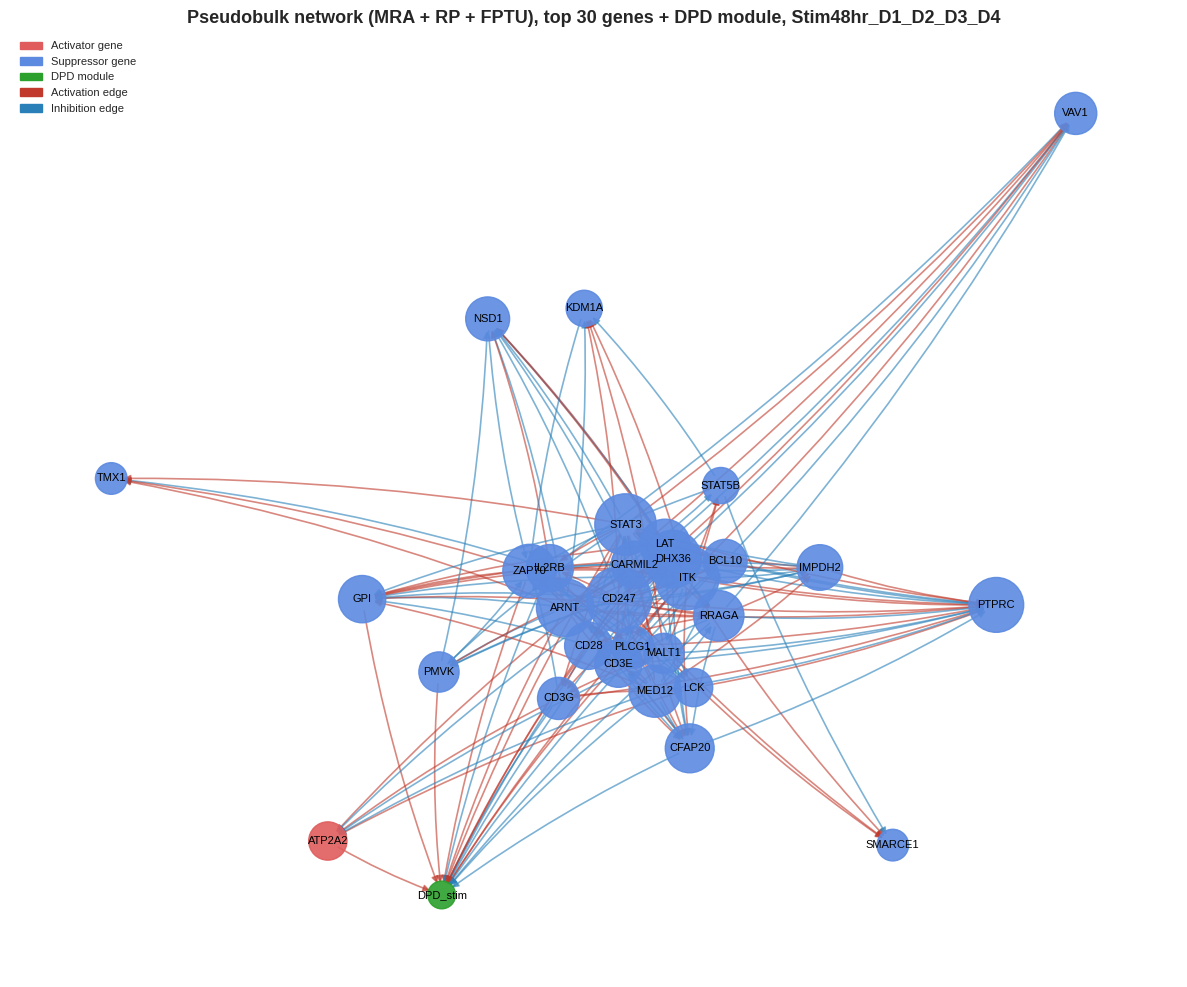

Saved: ../Results/Stim48hr/pseudobulk/network_graph_pseudobulk_Stim48hr_D1_D2_D3_D4.png


In [20]:
G_plot = nx.DiGraph()
G_plot.add_nodes_from(graph_nodes)
for _, row in edges_df.iterrows():
    G_plot.add_edge(row['source'], row['target'], edge_type=row['edge_type'], weight=abs(row['strength']))

degree = dict(G_plot.degree())
node_colors = []
node_sizes = []
for gene in G_plot.nodes():
    if gene in dpd_module_names:
        node_colors.append('#2ca02c')
        node_sizes.append(400)
    else:
        role_activator = dpd_stim_lookup.get(gene, 0) > 0
        node_colors.append('#e05c5c' if role_activator else '#5c8ae0')
        node_sizes.append(200 + degree.get(gene, 0) * 80)

edge_colors = ['#c0392b' if G_plot.edges[e]['edge_type'] == 'activation' else '#2980b9' for e in G_plot.edges()]

fig, ax = plt.subplots(figsize=(12, 10))
pos = nx.spring_layout(G_plot, seed=42, k=0.4)
nx.draw_networkx_nodes(G_plot, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G_plot, pos, edge_color=edge_colors, arrows=True, arrowsize=10,
                        width=1.2, alpha=0.6, connectionstyle='arc3,rad=0.05', ax=ax)
labels = {gene: gene for gene in G_plot.nodes() if degree.get(gene, 0) >= HUB_DEGREE_LABEL_MIN or gene in dpd_module_names}
nx.draw_networkx_labels(G_plot, pos, labels=labels, font_size=8, ax=ax)

legend_handles = [
    mpatches.Patch(color='#e05c5c', label='Activator gene'),
    mpatches.Patch(color='#5c8ae0', label='Suppressor gene'),
    mpatches.Patch(color='#2ca02c', label='DPD module'),
    mpatches.Patch(color='#c0392b', label='Activation edge'),
    mpatches.Patch(color='#2980b9', label='Inhibition edge'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=8)
ax.set_title(f'Pseudobulk network (MRA + RP + FPTU), top {TOP_N_HEATMAP} genes + DPD module, {run_tag}',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'network_graph_pseudobulk_{run_tag}.png')
plt.savefig(p, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

### 7b. Full-Network Edges (for comparison with single-cell)

Same threshold logic as Notebook 4's edge list, computed over **all** 200 genes (not restricted to `top_genes`), so the two can be compared on equal footing. `EDGE_STRENGTH_PERCENTILE` (80, used above for the readable graph) is deliberately different from `STRENGTH_PERCENTILE` (95, matching Notebook 4's default), this cell uses 95 to match NB4 exactly.

In [21]:
STRENGTH_PERCENTILE_FULL = 95  # matches Notebook 4's STRENGTH_PERCENTILE, for a fair comparison

off_diag_full = r.to_numpy()[~np.eye(N, dtype=bool)]
threshold_full = np.percentile(np.abs(off_diag_full), STRENGTH_PERCENTILE_FULL)
print(f'Full-network edge threshold ({STRENGTH_PERCENTILE_FULL}th percentile, all {N} genes): {threshold_full:.4f}')

edge_rows_full = []
for target in core_genes:
    for source in core_genes:
        if source == target:
            continue
        strength = r_total.loc[target, source]
        if abs(strength) >= threshold_full and strength != 0:
            edge_rows_full.append({
                'source': source, 'target': target, 'strength': strength,
                'edge_type': 'activation' if strength > 0 else 'inhibition',
            })

for module in dpd_module_names:
    for source in core_genes:
        strength = r_total.loc[module, source]
        if strength != 0:
            edge_rows_full.append({
                'source': source, 'target': module, 'strength': strength,
                'edge_type': 'activation' if strength > 0 else 'inhibition',
            })

edges_full_df = pd.DataFrame(edge_rows_full)
print(f'Full-network edges kept: {len(edges_full_df)}')

Full-network edge threshold (95th percentile, all 200 genes): 1.9012
Full-network edges kept: 2115


### 8. Cytoscape Export

`From / To / Strength`, tab-separated, built from the full `r_total` (not restricted to `top_genes`).

In [22]:
cyto_df = edges_df.rename(columns={'source': 'From', 'target': 'To', 'strength': 'Strength'})[['From', 'To', 'Strength']]
cyto_path = os.path.join(OUT_DIR, f'{run_tag}_cytoscape.txt')
cyto_df.to_csv(cyto_path, sep='\t', index=False)
print(f'Saved: {cyto_path} ({len(cyto_df)} edges, top N genes)')

Saved: ../Results/Stim48hr/pseudobulk/Stim48hr_D1_D2_D3_D4_cytoscape.txt (192 edges, top N genes)


### 9. Save

In [23]:
print('r diagonal check:', np.diag(r.values)[:5])
r.to_csv(os.path.join(OUT_DIR, f'r_{run_tag}.csv'))
r_fptu.to_csv(os.path.join(OUT_DIR, f'r_fptu_{run_tag}.csv'))
r_total.to_csv(os.path.join(OUT_DIR, f'r_total_{run_tag}.csv'))
r_minv.to_csv(os.path.join(OUT_DIR, f'r_minv_{run_tag}.csv'))
edges_df.to_csv(os.path.join(OUT_DIR, f'edges_{run_tag}.csv'), index=False)
edges_full_df.to_csv(os.path.join(OUT_DIR, f'edges_full_{run_tag}.csv'), index=False)
#diagnostics_summary.to_csv(os.path.join(OUT_DIR, f'diagnostics_{run_tag}.csv'), index=False)

node_table = core_df.copy()
node_table['total_degree'] = node_table['target_contrast_gene_name'].map(degree).fillna(0).astype(int)
node_table.to_csv(os.path.join(OUT_DIR, f'nodes_annotated_{run_tag}.csv'), index=False)

print(f'Done, {run_tag}')
print(f'Outputs in: {OUT_DIR}')

r diagonal check: [-1. -1. -1. -1. -1.]
Done, Stim48hr_D1_D2_D3_D4
Outputs in: ../Results/Stim48hr/pseudobulk
